(three-site-thouless-nb)=
# Three-site Thouless pump

We follow the three-orbital 1D Thouless pump through one adiabatic cycle, first in the periodic geometry and then as a finite chain. The onsite energies slide around the unit cell as the adiabatic parameter $\lambda$ sweeps from 0 to 1. Along the way we track Berry phases, Wannier centres, Chern numbers, and the edge modes that reveal the pumped charge.

:::{admonition} What you will learn
:class: tip
- Build the periodic three-site Thouless pump with `Lattice`, `TBModel`, and `Mesh`.
- Populate a `WFArray` over a mixed $(k,\lambda)$ grid and evaluate Berry phases, Wannier centres, and Chern numbers.
- Cut the model to a finite chain with `cut_piece`, solve its $\lambda$-dependent spectrum, and diagnose edge localisation via `position_expectation`.
- Relate the bulk Chern invariant to the pumped charge and to the edge-state crossings in the finite geometry.
:::

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from pythtb import Lattice, Mesh, TBModel, WFArray

## Lattice

The lattice stores both the real-space lattice vectors and the three orbital positions at reduced coordinates $0$, $1/3$, and $2/3$. This data is the common backbone for the `TBModel` and for any `WFArray` that samples its Bloch states.

In [2]:
lattice = Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0], [1 / 3], [2 / 3]], periodic_dirs=[0])

## Model builder

`set_model` constructs the periodic three-site Hamiltonian for a given hopping `t`, onsite amplitude `delta`, and pump parameter `lmbda`. The onsite terms follow a cosine profile delayed by $2\pi/3$ on each orbital so the deepest well moves from site 0 → 1 → 2 as $\lambda$ advances.

In [3]:
def set_model(t: float, delta: float, lmbda: float) -> TBModel:
    """Periodic three-site model at parameter lmbda."""
   
    model = TBModel(lattice=lattice)

    # nearest-neighbour hoppings (last hop wraps to the next cell)
    model.set_hop(t, 0, 1, [0])
    model.set_hop(t, 1, 2, [0])
    model.set_hop(t, 2, 0, [1])

    onsite = [delta * -np.cos(2 * np.pi * (lmbda - idx / 3)) for idx in range(3)]
    model.set_onsite(onsite)
    return model

## Mesh and wavefunctions

We sample the two-dimensional parameter space $(k,\lambda)$ with a `Mesh`. Axis names must match the keyword arguments in `set_model`; otherwise the solver would not vary the correct parameter. In our case we should name the parametric axis `"lmbda"`.

:::{tip}
`dim_k` and `dim_lambda` do not need to match the number of k- and $\lambda$- axes. For example, the mesh may define a path through a higher-dimensional Brillouin zone. 
:::

In [4]:
mesh = Mesh(
    dim_k=1,
    dim_lambda=1,
    axis_types=["k", "l"],   # first axis: crystal momentum; second: adiabatic parameter
    axis_names=["kx", "lmbda"],
)

We build a uniform $(k,\lambda)$ grid and enforce periodic boundary conditions along the $\lambda$ axis so that $\lambda=0$ and $\lambda=1$ are identified.

A few additional parameters are available to control the range of the parameter axis and whether to loop it.
In `mesh.build_grid`, we specify the start and stop values for the lambda parameter axis. By default, the endpoint is included along the lambda axes, while it is not included along the k axes.

:::{versionchanged} 2.0.0
In previous versions, `mesh.loop_axis(1,1)` would have been specified in `wf_array` by `impose_loop(1,1)`.
:::

In [5]:
mesh.build_grid(shape=(31, 21), gamma_centered=True, lambda_start=0.0, lambda_stop=1.0)
mesh.loop_axis(axis_idx=1, component_idx=1)  # form the lambda axis into a loop
mesh.close_axis(axis_idx=1, component_idx=1) # indicate that the end of the loop completes the cycle (endpoint included)
print(mesh)

Mesh Summary
Type: grid
Dimensionality: 1 k-dim(s) + 1 λ-dim(s)
Number of mesh points: 651
Full shape: (31, 21, 2)
k-axes: [Axis(type=k, name=kx, size=31)]
λ-axes: [Axis(type=l, name=lmbda, size=21)]
Is a torus in k-space (all k-axes wind BZ): yes
Looped axes: (axis 0 loops component 0), (axis 1 loops component 1)
BZ-winding axes: (axis 0 winds component 0)
Endpoint axes: (axis 1 contains endpoint of component 1)


With the mesh and lattice in place we initialize `WFArray`, fix `t` and `delta`, and call `solve_model`. The solver diagonalizes the Hamiltonian at every mesh point, stores the eigenvectors, and enforces periodic gauge conditions on the periodic k-axes automatically.

In [6]:
wfa = WFArray(lattice, mesh)

In [7]:
t = -1.3
delta = 2.0
fixed_params = {"t": t, "delta": delta}
wfa.solve_model(model_func=set_model, fixed_params=fixed_params)

## Berry flux and Chern numbers

The charge pumped per cycle equals the Chern number computed on the $(k,\lambda)$ torus. We evaluate the Berry curvature with `WFArray.chern_num` for individual bands and for cumulative fillings.

In [8]:
fillings = {
    "band 0": [0],
    "bands 0–1": [0, 1],
    "bands 0–2": [0, 1, 2],
}

cherns = {label: wfa.chern_num(state_idx=indices, plane=(0, 1)) for label, indices in fillings.items()}
band_cherns = {band: wfa.chern_num(state_idx=[band], plane=(0, 1)) for band in range(3)}

print("Individual band Chern numbers:")
for band, value in band_cherns.items():
    print(f"  band {band}     = {value:+5.2f}")

print("\nChern numbers by filling:")
for label, value in cherns.items():
    print(f"  {label:<10} = {value:+5.2f}")

Individual band Chern numbers:
  band 0     = -1.00
  band 1     = +2.00
  band 2     = -1.00

Chern numbers by filling:
  band 0     = -1.00
  bands 0–1  = +1.00
  bands 0–2  = +0.00


## Berry phase and Wannier centres

Another view of the pump is the Berry phase accumulated along the $k$ axis for each $\lambda$. Dividing that phase by $2\pi$ gives the Wannier center in reduced coordinates; its winding number must match the band Chern number.

We compute the Abelian Berry phase for each individual band with `WFArray.berry_phase` and convert it to the reduced Wannier center. A single $2\pi$ increase over the cycle signals a pumped charge of one electron per cell.

In [9]:
berry_phase0 = wfa.berry_phase(0, [0])
berry_phase1 = wfa.berry_phase(0, [1])
berry_phase2 = wfa.berry_phase(0, [2])

wann_center0 = berry_phase0 / (2*np.pi)
wann_center1 = berry_phase1 / (2*np.pi)
wann_center2 = berry_phase2 / (2*np.pi)

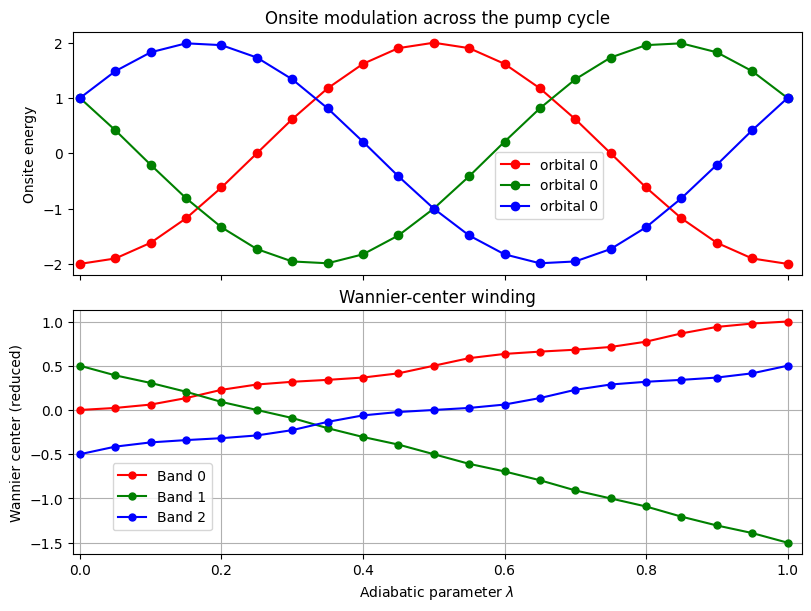

In [10]:
fig, (ax_onsite, ax_wann) = plt.subplots(
    2, 1, figsize=(8, 6), sharex=True, constrained_layout=True
)

all_lambda = mesh.get_param_points()[:, 0] 
onsite = np.vstack([
    delta * -np.cos(2 * np.pi * (all_lambda - shift / 3.0))
    for shift in range(3)
])

ax_onsite.plot(all_lambda, onsite[0], "ro-", label="orbital 0")
ax_onsite.plot(all_lambda, onsite[1], "go-", label="orbital 0")
ax_onsite.plot(all_lambda, onsite[2], "bo-", label="orbital 0")

ax_onsite.set_ylabel("Onsite energy")
ax_onsite.set_title("Onsite modulation across the pump cycle")
ax_onsite.legend(bbox_to_anchor=(0.57, 0.2))

ax_wann.plot(all_lambda, wann_center0, "ro-", ms=5, label='Band 0')
ax_wann.plot(all_lambda, wann_center1, "go-", ms=5, label='Band 1')
ax_wann.plot(all_lambda, wann_center2, "bo-", ms=5, label='Band 2')
ax_wann.grid()
ax_wann.legend(bbox_to_anchor=(0.2, 0.4))

ax_wann.set_xlabel(r"Adiabatic parameter $\lambda$")
ax_wann.set_ylabel("Wannier center (reduced)")
ax_wann.set_xlim(-0.01, 1.02)
ax_wann.set_title("Wannier-center winding")
plt.show()


## Finite chain setup

To expose the edge physics behind the pump, we cut a chain of `num_cells` unit cells from the periodic model. `cut_piece` removes the $k$ degree of freedom while keeping the hopping pattern intact.

In [11]:
num_cells = 10
num_orb = 3 * num_cells

def finite_model_builder(t: float, delta: float, lmbda: float) -> TBModel:
    periodic = set_model(t, delta, lmbda)
    return periodic.cut_piece(num_cells, 0)

The finite system has no crystal momentum axis, so the mesh tracks only the adiabatic parameter. We sample $\lambda$ densely enough to resolve the edge-state crossings.

In [12]:
finite_mesh = Mesh(dim_k=0, dim_lambda=1, axis_types=["l"], axis_names=["lmbda"])
finite_mesh.build_grid(shape=(241,), lambda_start=0.0, lambda_stop=1.0)
finite_mesh.loop_axis(0, 0)  # lambda axis and component now indexed by 0 
finite_mesh.close_axis(0, 0)
print(finite_mesh)

Mesh Summary
Type: grid
Dimensionality: 0 k-dim(s) + 1 λ-dim(s)
Number of mesh points: 241
Full shape: (241, 1)
k-axes: []
λ-axes: [Axis(type=l, name=lmbda, size=241)]
Is a torus in k-space (all k-axes wind BZ): yes
Looped axes: (axis 0 loops component 0)
BZ-winding axes: None
Endpoint axes: (axis 0 contains endpoint of component 0)


We initialize a new `WFArray` on the cut lattice and solve the Hamiltonian as $\lambda$ sweeps the cycle. 

In [13]:
finite_wfa = WFArray(lattice.cut_piece(num_cells, 0), finite_mesh)
finite_wfa.solve_model(model_func=finite_model_builder, fixed_params=fixed_params)

## Position expectation values

`WFArray.position_expectation(dir=0)` returns the $\langle x \rangle$ of each eigenstate in units of the lattice spacing. Bulk states cluster near the chain midpoint, while edge-localized states pin to either end.

In [12]:
x_expectation = finite_wfa.position_expectation(dir=0)

### Spectrum versus $\lambda$

Eigenenergies of the finite chain traced over the adiabatic cycle. Point color encodes the position expectation value $\langle x \rangle$: bulk states (green at the chain center) stay in the gap, while edge-localized states (dark/light extremes) thread the gap and connect the valence and conduction manifolds. This matches the non-zero Chern number found for the periodic system.

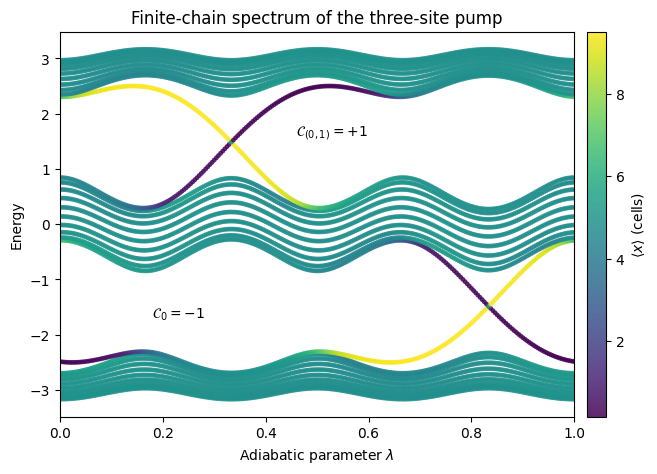

In [13]:
lambda_points = finite_mesh.get_param_points()
vmin, vmax = x_expectation.min(), x_expectation.max()
cmap = matplotlib.colormaps.get_cmap("viridis")

fig, ax = plt.subplots(figsize=(8, 5))

for orb in range(num_orb):
    sc = ax.scatter(
        lambda_points,
        finite_wfa.energies[:, orb],
        c=x_expectation[:, orb],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        s=12,
        edgecolors="none",
        alpha=0.85,
    )

cbar = fig.colorbar(sc, ax=ax, pad=0.02, label=r"$\langle x \rangle$ (cells)")

ax.text(0.18, -1.7, rf"$\mathcal{{C}}_0 = {cherns['band 0']:+1.0f}$")
ax.text(0.46, 1.6, rf"$\mathcal{{C}}_{{(0,1)}} = {cherns['bands 0–1']:+1.0f}$")

ax.set_title("Finite-chain spectrum of the three-site pump")
ax.set_xlabel(r"Adiabatic parameter $\lambda$")
ax.set_ylabel("Energy")
ax.set_xlim(0.0, 1.0)

plt.show()